<a href="https://colab.research.google.com/github/midorij347/-/blob/main/%E7%94%9F%E6%B6%AF%E5%8F%8E%E5%85%A5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install japanize-matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 77.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for japanize-matplotlib: filename=japanize_matplotlib-1.1.3-py3-none-any.whl size=4120257 sha256=f578d79f19f7a3e7f1cc4d6cc137bcbb19918c34b96eac7336829f6506433344
  Stored in directory: /root/.cache/pip/wheels/c1/f7/9b/418f19a7b9340fc16e071e89efc379aca68d40238b258df53d
Successfully built japanize-matplotlib


=== 生涯収入 summary (円) ===
平均: 142,093,527
中央値: 131,190,967
10%点: 77,323,052
25%点: 100,091,296
75%点: 170,310,423
90%点: 216,435,790

=== 億円表示 ===
平均: 1.421 億円
中央値: 1.312 億円
10%点: 0.773 億円
25%点: 1.001 億円
75%点: 1.703 億円
90%点: 2.164 億円


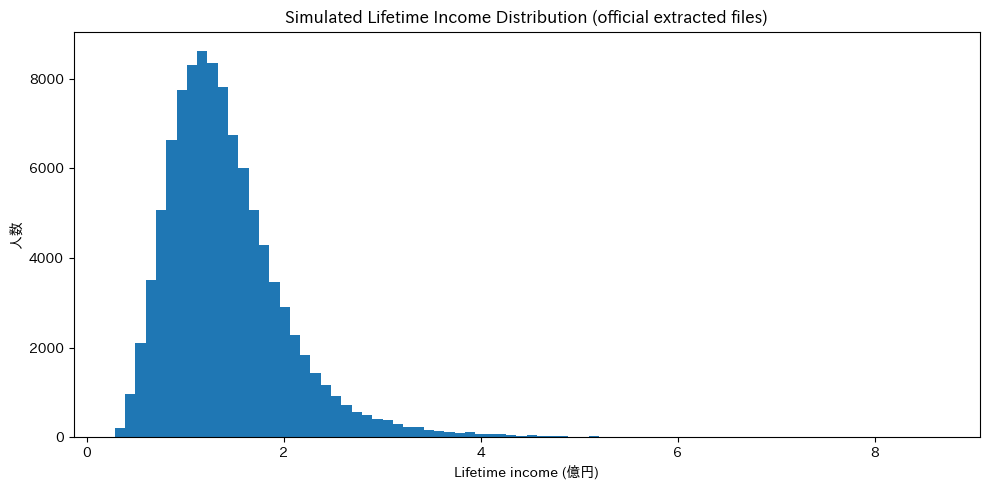

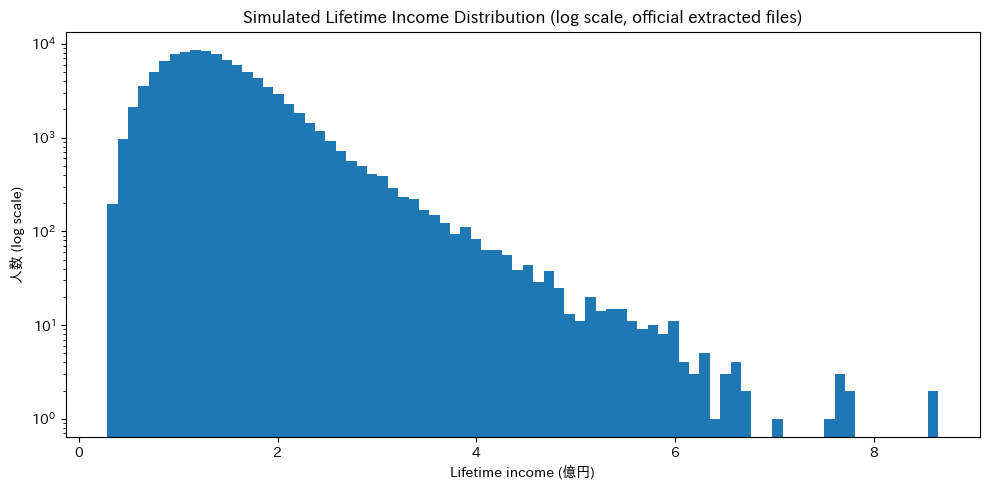

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

try:
    import japanize_matplotlib  # noqa: F401
except Exception:
    japanize_matplotlib = None

# Colab では __file__ がないことがあるので、カレントディレクトリ基準にする
BASE_DIR = Path.cwd()

AGE_SALARY_CSV = BASE_DIR / 'nta_2024_age_avg_salary.csv'
BRACKETS_CSV = BASE_DIR / 'nta_2024_salary_brackets_total.csv'
EMPLOYMENT_MIX_CSV = BASE_DIR / 'stat_age_employment_mix_2022.csv'


def load_official_wage_curve(
    age_salary_csv: Path = AGE_SALARY_CSV,
    employment_mix_csv: Path = EMPLOYMENT_MIX_CSV,
) -> pd.DataFrame:
    age_salary = pd.read_csv(age_salary_csv)
    employment_mix = pd.read_csv(employment_mix_csv)

    band_to_ages = {
        '２０～２４': range(20, 25),
        '２５～２９': range(25, 30),
        '３０～３４': range(30, 35),
        '３５～３９': range(35, 40),
        '４０～４４': range(40, 45),
        '４５～４９': range(45, 50),
        '５０～５４': range(50, 55),
        '５５～５９': range(55, 60),
        '６０～６４': range(60, 65),
    }

    def age_to_emp_group(age: int) -> str:
        if age <= 24:
            return '15-24 (excluding students)'
        elif age <= 34:
            return '25-34'
        elif age <= 44:
            return '35-44'
        elif age <= 54:
            return '45-54'
        elif age <= 64:
            return '55-64'
        return '65+'

    emp_map = employment_mix.set_index('age_group').to_dict(orient='index')

    rows = []
    for _, src in age_salary.iterrows():
        band = src['age_band']
        if band not in band_to_ages:
            continue

        total_income = float(src['total_avg_salary_yen'])
        for age in band_to_ages[band]:
            if age < 22 or age > 60:
                continue

            emp_group = age_to_emp_group(age)
            emp = emp_map[emp_group]
            p_regular = float(emp['regular_share_pct']) / 100.0
            p_nonregular = float(emp['nonregular_share_pct']) / 100.0
            p_nonemployed = 0.0

            rows.append({
                'age': age,
                'mean_income_regular': total_income,
                'mean_income_nonregular': total_income * 0.75,
                'p_regular': p_regular,
                'p_nonregular': p_nonregular,
                'p_nonemployed': p_nonemployed,
            })

    return pd.DataFrame(rows).sort_values('age').reset_index(drop=True)



def load_official_income_brackets(brackets_csv: Path = BRACKETS_CSV) -> pd.DataFrame:
    src = pd.read_csv(brackets_csv)
    bands = ['20s', '30s', '40s', '50s']
    rows = []

    for band in bands:
        for _, r in src.iterrows():
            lower = pd.to_numeric(r['lower_yen'], errors='coerce')
            upper = pd.to_numeric(r['upper_yen'], errors='coerce')
            rows.append({
                'age_band': band,
                'lower': None if pd.isna(lower) else int(lower),
                'upper': None if pd.isna(upper) else int(upper),
                'prob': float(r['probability']),
                'repr_value': int(r['avg_salary_yen_within_bracket']),
                'open_upper': bool(r['open_upper']),
                'bracket_label': r['bracket_label'],
            })

    return pd.DataFrame(rows)



def age_to_band(age):
    if 20 <= age <= 29:
        return '20s'
    elif 30 <= age <= 39:
        return '30s'
    elif 40 <= age <= 49:
        return '40s'
    else:
        return '50s'



def build_multiplier_table(brackets_df):
    result = {}
    for band, g in brackets_df.groupby('age_band'):
        values = g['repr_value'].astype(float).values
        probs = g['prob'].astype(float).values
        probs = probs / probs.sum()
        mean_val = np.sum(values * probs)
        multipliers = values / mean_val

        result[band] = {
            'values': values,
            'probs': probs,
            'multipliers': multipliers,
        }
    return result



def choose_state(row, rng):
    probs = np.array([
        row['p_regular'],
        row['p_nonregular'],
        row['p_nonemployed'],
    ], dtype=float)
    probs = probs / probs.sum()
    return rng.choice([0, 1, 2], p=probs)



def simulate_lifetime_income(
    wage_curve_df,
    brackets_df,
    n_people=100000,
    rho=0.85,
    annual_shock_std=0.12,
    seed=42,
):
    rng = np.random.default_rng(seed)
    ages = wage_curve_df['age'].values
    multiplier_table = build_multiplier_table(brackets_df)

    latent_skill = rng.normal(loc=0.0, scale=1.0, size=n_people)
    lifetime_income = np.zeros(n_people)
    panel_records = []

    for age in ages:
        row = wage_curve_df[wage_curve_df['age'] == age].iloc[0]
        band = age_to_band(age)
        info = multiplier_table[band]

        sorted_idx = np.argsort(latent_skill)
        ranks = np.empty(n_people, dtype=int)
        ranks[sorted_idx] = np.arange(n_people)

        u = (ranks + 0.5) / n_people
        cdf = np.cumsum(info['probs'])
        bracket_idx = np.searchsorted(cdf, u, side='right')
        bracket_idx = np.clip(bracket_idx, 0, len(info['multipliers']) - 1)

        base_multiplier = info['multipliers'][bracket_idx]
        shock = np.exp(rng.normal(0, annual_shock_std, size=n_people))
        states = np.array([choose_state(row, rng) for _ in range(n_people)])
        incomes = np.zeros(n_people)

        mask_reg = states == 0
        incomes[mask_reg] = row['mean_income_regular'] * base_multiplier[mask_reg] * shock[mask_reg]

        mask_nonreg = states == 1
        incomes[mask_nonreg] = (
            row['mean_income_nonregular']
            * (0.85 * base_multiplier[mask_nonreg] + 0.15)
            * shock[mask_nonreg]
        )

        lifetime_income += incomes
        latent_skill = rho * latent_skill + np.sqrt(1 - rho**2) * rng.normal(size=n_people)

        if age in [22, 30, 40, 50, 60]:
            sample_idx = rng.choice(n_people, size=min(3000, n_people), replace=False)
            temp_df = pd.DataFrame({
                'age': age,
                'state': states[sample_idx],
                'income': incomes[sample_idx],
            })
            panel_records.append(temp_df)

    panel_df = pd.concat(panel_records, ignore_index=True) if panel_records else pd.DataFrame()
    return lifetime_income, panel_df



def main():
    wage_curve_df = load_official_wage_curve()
    brackets_df = load_official_income_brackets()

    lifetime_income, panel_df = simulate_lifetime_income(
        wage_curve_df,
        brackets_df,
        n_people=100000,
        rho=0.90,
        annual_shock_std=0.10,
        seed=123,
    )

    summary = {
        '平均': lifetime_income.mean(),
        '中央値': np.median(lifetime_income),
        '10%点': np.quantile(lifetime_income, 0.10),
        '25%点': np.quantile(lifetime_income, 0.25),
        '75%点': np.quantile(lifetime_income, 0.75),
        '90%点': np.quantile(lifetime_income, 0.90),
    }

    print('=== 生涯収入 summary (円) ===')
    for k, v in summary.items():
        print(f'{k}: {v:,.0f}')

    print('\n=== 億円表示 ===')
    for k, v in summary.items():
        print(f'{k}: {v / 1e8:.3f} 億円')

    plt.figure(figsize=(10, 5))
    plt.hist(lifetime_income / 1e8, bins=80)
    plt.xlabel('Lifetime income (億円)')
    plt.ylabel('人数')
    plt.title('Simulated Lifetime Income Distribution (official extracted files)')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.hist(lifetime_income / 1e8, bins=80, log=True)
    plt.xlabel('Lifetime income (億円)')
    plt.ylabel('人数 (log scale)')
    plt.title('Simulated Lifetime Income Distribution (log scale, official extracted files)')
    plt.tight_layout()
    plt.show()

    return lifetime_income, panel_df, wage_curve_df, brackets_df


if __name__ == '__main__':
    main()
